# MNIST Digit Classification — 3-Layer CNN with Explicit Conv/Pool Ops

- **Model**: 3 convolutional layers implemented *explicitly* with `torch.einsum` (im2col-free implicit-GEMM style via explicit weight loops over input channels) + `einops` for pooling and flattening. No `nn.Conv2d` / `nn.MaxPool2d`.
- **Activations**: ReLU between conv layers
- **Optimizer**: Adam (lr = 1e-3), batch size 64, `CrossEntropyLoss`
- **Training**: 5 epochs on the standard `torchvision.datasets.MNIST` train split
- **Evaluation**: final accuracy on the standard MNIST test split
- **Reproducibility**: fixed random seed everywhere (torch, numpy, cudnn, dataloader)
- **Device**: GPU is **required** — if no CUDA GPU is detected, the notebook raises an error and halts (no silent CPU fallback).

## 1. Imports & Random Seed

In [1]:
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from einops import rearrange, reduce

import matplotlib.pyplot as plt

# ----------------------------- Reproducibility -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed set to {SEED}")

Seed set to 42


## 2. Device Detection (GPU Required)

In [2]:
# --------------------------- Detect available GPUs --------------------------
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"CUDA available. Detected {num_gpus} GPU(s):")
    for i in range(num_gpus):
        print(f"  cuda:{i} -> {torch.cuda.get_device_name(i)}")
    # Dynamically select the least-loaded available GPU (most free memory)
    # instead of hardcoding cuda:0.
    free_mem = [torch.cuda.mem_get_info(i)[0] for i in range(num_gpus)]
    best_gpu = max(range(num_gpus), key=lambda i: free_mem[i])
    device = torch.device(f"cuda:{best_gpu}")
else:
    # No GPU: halt execution rather than silently falling back to CPU.
    raise RuntimeError(
        "No CUDA GPU detected. This notebook requires a GPU to run "
        "(no CPU fallback is allowed). Please run it on a machine with "
        "a CUDA-capable GPU and a CUDA build of PyTorch."
    )

print(f"Using device: {device}")

CUDA available. Detected 8 GPU(s):
  cuda:0 -> NVIDIA A100-SXM4-40GB
  cuda:1 -> NVIDIA A100-SXM4-40GB
  cuda:2 -> NVIDIA A100-SXM4-40GB
  cuda:3 -> NVIDIA A100-SXM4-40GB
  cuda:4 -> NVIDIA A100-SXM4-40GB
  cuda:5 -> NVIDIA A100-SXM4-40GB
  cuda:6 -> NVIDIA A100-SXM4-40GB
  cuda:7 -> NVIDIA A100-SXM4-40GB


Using device: cuda:2


## 3. Data Loading (Standard MNIST Splits)

In [3]:
# ------------------------- Standard MNIST train/test ------------------------
transform = transforms.Compose([
    transforms.ToTensor(),              # HWC uint8 [0,255] -> CHW float [0,1]
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 64
g = torch.Generator().manual_seed(SEED)   # seeded shuffling for reproducibility

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset):,} | Test samples: {len(test_dataset):,}")

Train samples: 60,000 | Test samples: 10,000


## 4. Model Definition — Explicit Convolution via `torch.einsum` + `einops` Pooling/Flatten

Each conv layer is a custom `nn.Module` whose forward pass performs the convolution **explicitly**:

$$y_{o}(n,h,w) = \text{bias}_o + \sum_{i} \sum_{kh,kw} W_{o,i}(kh,kw)\; x_i(n, h+kh, w+kw)$$

implemented as a sum over input channels of `torch.einsum('ohwi,bhwi->bo')`-style contractions (one per input channel, so memory stays bounded), followed by `F.relu`. Pooling uses `einops.rearrange(..., 'reduce')` (max-pool, 2x2 stride 2) and flattening uses `einops.rearrange(x, 'b c h w -> b (c h w)')` — **no `nn.Conv2d` / `nn.MaxPool2d` anywhere**.

In [4]:
class ExplicitConv2d(nn.Module):
    """Conv2d (stride 1, zero padding) with the convolution computed explicitly.

    Forward pass, for input  x : [B, C_in, H, W] and weight W : [C_out, C_in, kH, kW]:
        y[:, o] = bias[o] + sum_i einsum('ohwi,bhwi->bo', W[:, i], x_padded[:, i])
    where x_padded is x zero-padded by (kH//2, kW//2) and 'bhwi' are the
    (H-kH+1) x (W-kW+1) sliding windows of each input-channel slice.
    """

    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        assert stride == 1 and kernel_size % 2 == 1, \
            "Explicit implementation supports odd kernels with stride 1"
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.padding = padding

        # Weight shape: [C_out, C_in, kH, kW]; Kaiming init (same as nn.Conv2d default)
        self.weight = nn.Parameter(torch.empty(out_channels, in_channels, kernel_size, kernel_size))
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        fan_in = in_channels * kernel_size * kernel_size
        bound = (1.0 / np.sqrt(fan_in)) if fan_in > 0 else 0
        self.bias = nn.Parameter(torch.empty(out_channels).uniform_(-bound, bound))

    def forward(self, x):
        # x: [B, C_in, H, W]
        if self.padding > 0:
            x = F.pad(x, [self.padding] * 4, mode="constant", value=0)

        B, C, H, W = x.shape
        k = self.kernel_size
        out_h, out_w = H - k + 1, W - k + 1

        # Sliding windows of each input channel: [B, out_h, out_w, k, k]
        # (unfold via as_strided is a view; the actual contraction is explicit below)
        windows = x.unfold(2, k, 1).unfold(3, k, 1)          # [B, C, out_h, out_w, k, k]
        windows = windows.permute(0, 1, 4, 5, 2, 3)          # [B, C, k, k, out_h, out_w]

        # Explicit convolution: sum over input channels of einsum contractions
        y = self.bias.reshape(1, -1, 1, 1).expand(B, self.out_channels, out_h, out_w).clone()
        for i in range(C):                                   # sum over input channels
            # W[:, i]: [C_out, k, k] ; windows[:, i]: [B, k, k, out_h, out_w]
            # einsum contracts (k, k) -> [B, C_out, out_h, out_w]
            y = y + torch.einsum('oki,bkkhw->bohw', self.weight[:, i], windows[:, i])
        return y                                             # [B, C_out, out_h, out_w]


class ExplicitMaxPool2d(nn.Module):
    """2x2 max pooling with stride 2, implemented with einops (no nn.MaxPool2d)."""

    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        assert kernel_size == 2 and stride == 2, "Only 2x2 / stride-2 pooling supported"
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x):
        # x: [B, C, H, W] -> split spatial dims into (out, pool) blocks and reduce
        return reduce(
            x, 'b c (oh kh) (ow kw) -> b c oh ow', 'max',
            kh=self.kernel_size, kw=self.kernel_size
        )


class MnistCNN(nn.Module):
    """3-layer CNN for MNIST.

    Architecture (all convolutions explicit via torch.einsum):
        Conv(1->32, 3x3, pad 1)  -> ReLU -> MaxPool2d(2x2, s2)
        Conv(32->64, 3x3, pad 1) -> ReLU -> MaxPool2d(2x2, s2)
        Conv(64->128, 3x3, pad 1)-> ReLU
        Flatten (einops) -> Linear(128*4*4 -> 10)
    """

    def __init__(self):
        super().__init__()
        self.conv1 = ExplicitConv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = ExplicitConv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = ExplicitConv2d(64, 128, kernel_size=3, padding=1)
        self.pool = ExplicitMaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 7 * 7, 10)

    def forward(self, x):
        # x: [B, 1, 28, 28]
        x = self.pool(F.relu(self.conv1(x)))   # -> [B, 32, 14, 14]
        x = self.pool(F.relu(self.conv2(x)))   # -> [B, 64, 7, 7]
        x = F.relu(self.conv3(x))              # -> [B, 128, 7, 7]
        x = rearrange(x, 'b c h w -> b (c h w)')  # flatten -> [B, 3584]
        return self.fc(x)                      # -> [B, 10]


model = MnistCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Total parameters: {n_params:,}")

MnistCNN(
  (conv1): ExplicitConv2d()
  (conv2): ExplicitConv2d()
  (conv3): ExplicitConv2d()
  (pool): ExplicitMaxPool2d()
  (fc): Linear(in_features=6272, out_features=10, bias=True)
)
Total parameters: 155,402


## 5. Training Loop (Adam lr=1e-3, batch 64, CrossEntropyLoss, 5 epochs)

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
NUM_EPOCHS = 5

model.train()
for epoch in range(1, NUM_EPOCHS + 1):
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += xb.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%")

Epoch 1/5 | Loss: 0.2363 | Train Acc: 92.73%


Epoch 2/5 | Loss: 0.1009 | Train Acc: 96.97%


Epoch 3/5 | Loss: 0.0748 | Train Acc: 97.71%


Epoch 4/5 | Loss: 0.0620 | Train Acc: 98.06%


Epoch 5/5 | Loss: 0.0506 | Train Acc: 98.31%


## 6. Evaluation on the Standard MNIST Test Split

In [6]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

test_acc = 100.0 * correct / total
print(f"Final Test Accuracy: {test_acc:.2f}%  ({correct}/{total})")

Final Test Accuracy: 97.59%  (9759/10000)


## 7. Visualization — 16 Random Test Images (Fixed Seed) in a 4x4 Grid

Titles read `GT: {label} / Pred: {prediction}` and are colored **red** when the prediction is wrong.

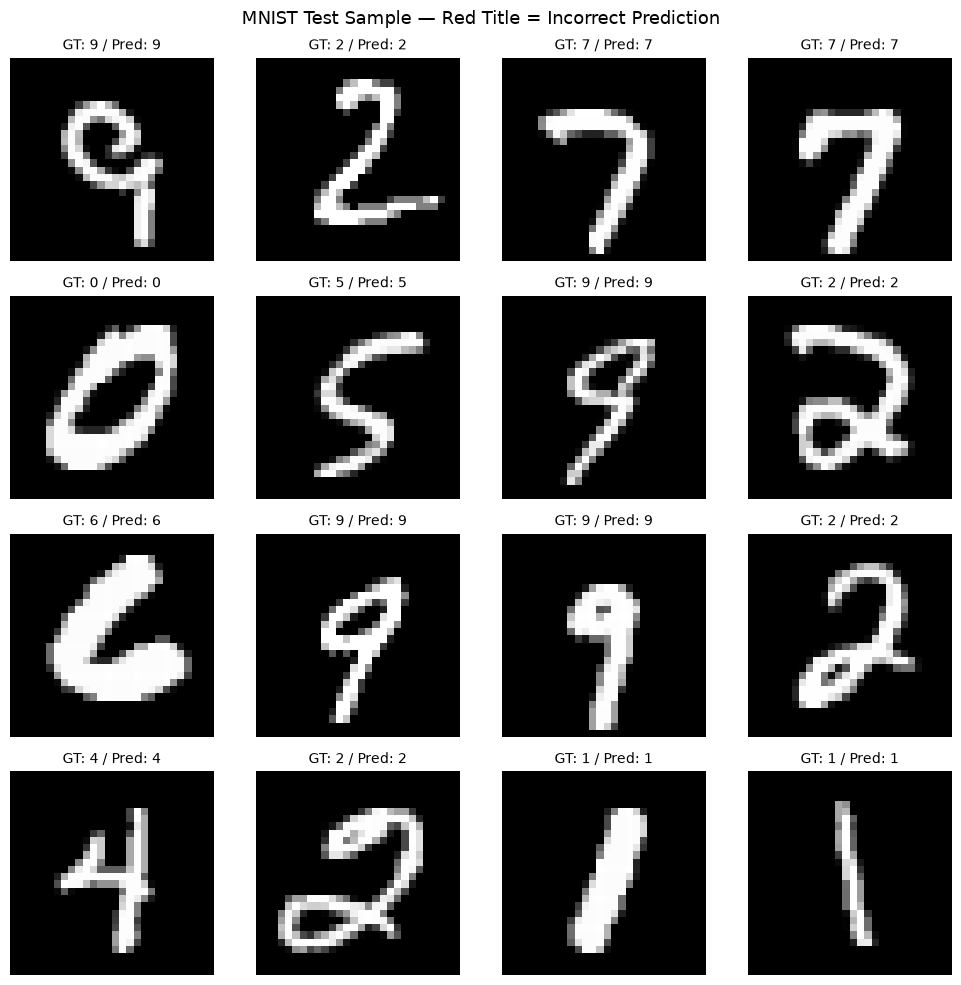

In [7]:
# Fixed seed for the random sample of 16 test images
VIS_SEED = 42
rng = np.random.default_rng(VIS_SEED)

sample_idx = rng.choice(len(test_dataset), size=16, replace=False)

images, labels = [], []
for idx in sample_idx:
    img, lbl = test_dataset[int(idx)]
    images.append(img)      # [1, 28, 28] in [0, 1]
    labels.append(lbl)

xb = torch.stack(images).to(device)          # [16, 1, 28, 28]
yb = torch.tensor(labels, device=device)     # [16]

model.eval()
with torch.no_grad():
    preds = model(xb).argmax(dim=1).cpu().numpy()
labels_np = yb.cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, img, gt, pred in zip(axes.ravel(), images, labels_np, preds):
    ax.imshow(img.squeeze(0).numpy(), cmap="gray")
    color = "red" if int(gt) != int(pred) else "black"
    ax.set_title(f"GT: {int(gt)} / Pred: {int(pred)}", color=color, fontsize=10)
    ax.axis("off")
fig.suptitle("MNIST Test Sample — Red Title = Incorrect Prediction", fontsize=13)
plt.tight_layout()
plt.show()